# Puntos Bi: réplica en miniatura del sistema de recompensas

Caso de estudio 2 · Machine Learning Engineering (CC3105)

Repositorio: https://github.com/JosueSay/ml-engineering-portfolio/tree/main/case-studies/reward-system

Este notebook es la prueba funcional del diagnóstico. Reconstruye en pequeño la arquitectura de datos del programa Puntos Bi de Banco Industrial, desde la extracción hasta el saldo que ve el cliente, y la usa para comprobar los hallazgos del reporte con números.

Los datos son sintéticos. El banco no publica datos de clientes y no se usó ninguno. Las reglas sí son las del programa: el motor las lee de config/assumptions.yaml, donde cada una lleva su fuente y su nivel de confianza. Lo que el banco no publica y el motor necesita para correr está en config/poc-parameters.yaml, y cada valor apunta a la pregunta abierta que lo reemplazaría.

Cualquier cifra de este notebook demuestra un mecanismo. Ninguna mide el programa real.

| Sección | Qué hace |
|---|---|
| 1. Configuración | Carga las reglas y los parámetros |
| 2. Extracción | Genera los archivos que entregarían los sistemas de origen |
| 3. Bronze | Copia intacta de lo que entró |
| 4. Silver | Limpieza, filtrado y resolución del rubro |
| 5. Motor de acumulación | Tasas, campaña, tope anual y latencia |
| 6. Gold | Ledger de lotes, canje, expiración y saldo |
| 7. Lo que muestra la réplica | Los hallazgos del reporte, medidos sobre la réplica |
| 8. Dónde entra el modelo | El punto de injerto de la propuesta de ML |
| 9. Conclusiones y referencias | |

## 1. Configuración

Dos archivos, con papeles distintos. assumptions.yaml documenta el sistema y no contiene ningún número inventado. poc-parameters.yaml contiene los supuestos del equipo. Separarlos permite que, cuando el banco responda una pregunta, se cambie un valor y el notebook vuelva a correr sin tocar el código.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.width", 120)

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
REGLAS = yaml.safe_load((RAIZ / "config/assumptions.yaml").read_text(encoding="utf-8"))
POC = yaml.safe_load((RAIZ / "config/poc-parameters.yaml").read_text(encoding="utf-8"))
SIM = POC["simulacion"]

RAW = RAIZ / "data/raw"
BRONZE, SILVER, GOLD = (RAIZ / f"data/processed/{capa}" for capa in ("bronze", "silver", "gold"))
for carpeta in (RAW, BRONZE, SILVER, GOLD):
    carpeta.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(SIM["semilla"])

In [2]:
acum = REGLAS["acumulacion_transaccional"]
saldos_cfg = REGLAS["acumulacion_por_saldos"]

TASA_BASE = acum["tasa_base"]["puntos_por_dolar"]
TASA_REDUCIDA = acum["tasa_categorias_reducidas"]["puntos_por_dolar"]
TOPES = acum["topes_anuales"]["valor"]
UMBRALES = saldos_cfg["saldo_minimo_mensual_gtq"]["valor"]
FACTOR_MEMBRESIA = saldos_cfg["multiplicador_por_membresia"]["factor"]
VIGENCIA_ANIOS = REGLAS["vigencia"]["anios"]["valor"]
CORTE_MES, CORTE_DIA = REGLAS["vigencia"]["corte"]["mes"], REGLAS["vigencia"]["corte"]["dia"]
PERMANENCIA_MESES = REGLAS["unificacion_familiar"]["permanencia_minima_meses"]["valor"]
GTQ_POR_PUNTO_CANJE = REGLAS["canje"]["valor_del_punto"]["valor"]["gtq_por_punto"]
CAMPANA = REGLAS["promociones"]["ejemplo_multiplicador"]["valor"]
SORTEO = REGLAS["promociones"]["ejemplo_sorteo"]["valor"]

TC = POC["tipo_de_cambio_gtq_usd"]["valor"]
GTQ_SALDO_POR_PUNTO = POC["saldos_promedio_gtq_por_punto"]["valor"]
ORDEN_LOTES = POC["consumo_de_lotes"]["valor"]
MILLAS = POC["millas_por_punto_segun_origen"]["valor"]
CUENTA_DOBLE = POC["cuenta_con_doble_por_membresia"]["valor"]
GRANO_TOPE = POC["grano_del_tope_anual"]["valor"]
MCC_REDUCIDO = set(POC["rubros_de_tasa_reducida"]["valor"])
MCC_EXCLUIDO = set(POC["rubros_excluidos"]["valor"])

pd.DataFrame(
    [
        ("Tasa base (puntos por US$)", TASA_BASE, acum["tasa_base"]["confianza"], ""),
        ("Tasa reducida (puntos por US$)", TASA_REDUCIDA, acum["tasa_categorias_reducidas"]["confianza"], ""),
        ("Topes anuales publicados", len(TOPES), acum["topes_anuales"]["confianza"], ""),
        ("Corte de vigencia", f"{CORTE_DIA}/{CORTE_MES}, {VIGENCIA_ANIOS} años", "publico", ""),
        ("Permanencia de la unificación (meses)", PERMANENCIA_MESES, "publico", ""),
        ("Quetzales por punto al canjear", GTQ_POR_PUNTO_CANJE, "publico", ""),
        ("Tipo de cambio GTQ/USD", TC, "supuesto", "P-3"),
        ("Quetzales de saldo promedio por punto", GTQ_SALDO_POR_PUNTO, "supuesto", "P-2"),
        ("Orden de consumo de lotes", ORDEN_LOTES, "supuesto", "P-4"),
        ("Grano del tope anual", GRANO_TOPE, "supuesto", "P-1"),
        ("Cuenta con doble por membresía", CUENTA_DOBLE, "supuesto", "P-12"),
    ],
    columns=["parámetro", "valor", "confianza", "sustituye a"],
).astype({"valor": str})

,parámetro,valor,confianza,sustituye a
0,Tasa base (puntos por US$),1.0,publico,
1,Tasa reducida (puntos por US$),0.1,publico,
2,Topes anuales publicados,4,publico,
3,Corte de vigencia,"5/2, 2 años",publico,
4,Permanencia de la unificación (meses),12,publico,
5,Quetzales por punto al canjear,0.0619,publico,
6,Tipo de cambio GTQ/USD,7.7,supuesto,P-3
7,Quetzales de saldo promedio por punto,1000.0,supuesto,P-2
8,Orden de consumo de lotes,fifo,supuesto,P-4
9,Grano del tope anual,grupo_familiar,supuesto,P-1


## 2. Extracción

El diagrama de arquitectura identifica cuatro orígenes: el core bancario, el autorizador de tarjetas (NeoNet), Bi en Línea y los centros de canje. Aquí se simulan los archivos que cada uno entregaría al pipeline:

| Archivo | Sistema de origen |
|---|---|
| clientes, grupos, tarjetas, cuentas | Core bancario |
| transacciones | Autorizador de tarjetas |
| saldos_promedio | Core de depósitos, al cierre de mes |
| campanas, inscripciones, premios_sorteo | Motor de campañas |
| solicitudes_canje | Centros de canje |

Los datos traen a propósito los defectos que el diagnóstico espera del sistema real: reintentos duplicados, reversas como fila aparte, consumos sin código de rubro, montos en dólares, montos con separador de miles y filas fuera de orden. Sin esos defectos la capa Silver no tendría nada que hacer.

In [3]:
INICIO = pd.Timestamp(SIM["inicio"])
FIN = INICIO + pd.DateOffset(months=SIM["meses"]) - pd.Timedelta(days=1)
MESES = pd.period_range(INICIO, FIN, freq="M")
n_cli, n_grp = SIM["n_clientes"], SIM["n_grupos_familiares"]

grupo_de = np.concatenate([np.arange(n_grp), rng.integers(0, n_grp, n_cli - n_grp)])
clientes = pd.DataFrame({
    "cliente_id": [f"C{i:04d}" for i in range(n_cli)],
    "grupo_id": [f"G{g:03d}" for g in grupo_de],
    "membresia_club_bi": rng.random(n_cli) >= SIM["tasa_sin_membresia_club_bi"],
    "bi_movil_activo": rng.random(n_cli) >= SIM["tasa_sin_bi_movil"],
})

miembros = clientes.groupby("grupo_id").size()
grupos = pd.DataFrame({"grupo_id": miembros.index, "miembros": miembros.values})
grupos["titular_id"] = "C" + grupos["grupo_id"].str[1:].astype(int).map("{:04d}".format)
ventana = (pd.Timestamp("2026-03-31") - pd.Timestamp("2022-01-01")).days
desde = pd.Timestamp("2022-01-01") + pd.to_timedelta(rng.integers(0, ventana, len(grupos)), unit="D")
grupos["unificacion_desde"] = pd.Series(desde).where(grupos["miembros"] > 1)

# Unos pocos grupos de alto consumo, para que el tope anual llegue a actuar.
alto_consumo_grupos = rng.choice(grupos.loc[grupos["miembros"] >= 3, "grupo_id"], 8, replace=False)
alto_consumo = clientes["grupo_id"].isin(alto_consumo_grupos).to_numpy()

In [4]:
PRODUCTOS = pd.DataFrame([
    ("visa_clasica", "visa", "credito_visa", 0.20),
    ("visa_premier", "visa", "credito_visa", 0.10),
    ("visa_platinum", "visa", "credito_visa", 0.07),
    ("visa_signature", "visa", "credito_visa", 0.04),
    ("visa_infinite", "visa", "credito_visa", 0.02),
    ("mastercard_standard", "mastercard", "credito_mastercard", 0.08),
    ("mastercard_gold_internacional", "mastercard", "credito_mastercard", 0.05),
    ("mastercard_platinum", "mastercard", "credito_mastercard", 0.03),
    ("mastercard_black", "mastercard", "credito_mastercard", 0.02),
    ("bi_cheque_visa", "visa", "debito_visa", 0.22),
    ("debito_mastercard", "mastercard", "debito_mastercard", 0.10),
    ("dividelo_todo", "visa", "dividelo_todo", 0.07),
], columns=["producto", "marca", "origen", "peso"])

n_tarjetas = 1 + (rng.random(n_cli) < 0.4) * ~alto_consumo
duenio = np.repeat(np.arange(n_cli), n_tarjetas)
producto = rng.choice(PRODUCTOS["producto"], len(duenio), p=PRODUCTOS["peso"])
producto = np.where(alto_consumo[duenio], "visa_premier", producto)

tarjetas = pd.DataFrame({
    "tarjeta_id": [f"T{i:05d}" for i in range(len(duenio))],
    "cliente_id": clientes["cliente_id"].to_numpy()[duenio],
    "producto": producto,
}).merge(PRODUCTOS[["producto", "marca", "origen"]], on="producto", how="left")
es_mc_credito = tarjetas["origen"] == "credito_mastercard"
tarjetas["afiliada_mc"] = es_mc_credito & (rng.random(len(tarjetas)) >= SIM["tasa_mastercard_no_afiliada"])
tarjetas["acumula"] = np.where(es_mc_credito, tarjetas["afiliada_mc"], rng.random(len(tarjetas)) >= 0.03)
tarjetas["tope_anual"] = tarjetas["producto"].map(TOPES)

tarjetas.groupby("origen").agg(tarjetas=("tarjeta_id", "size"), acumulan=("acumula", "mean"))

,tarjetas,acumulan
origen,,
credito_mastercard,197,0.36
credito_visa,422,0.95
debito_mastercard,94,0.95
debito_visa,176,0.99
dividelo_todo,68,0.94


In [5]:
COMERCIOS = pd.DataFrame([
    ("SUPER24 ZONA 10 GT", "5411", 0.12, 350), ("PAIZ ROOSEVELT", "5411", 0.10, 420),
    ("LA TORRE MIXCO", "5411", 0.08, 380), ("SHELL LAS AMERICAS", "5541", 0.08, 300),
    ("PUMA ZONA 9", "5541", 0.06, 280), ("STAR MART TXC ZONA 4", "5499", 0.05, 60),
    ("COLEGIO SAN JOSE", "8211", 0.02, 1200), ("UNIVERSIDAD GALILEO", "8220", 0.01, 1800),
    ("FUNDACION PAIS", "8398", 0.01, 150), ("POLLO CAMPERO 14", "5812", 0.10, 110),
    ("PIZZA HUT PRADERA", "5812", 0.05, 160), ("FARMACIA GALENO MIXCO", "5912", 0.06, 190),
    ("CEMACO OAKLAND", "5200", 0.04, 650), ("ELEKTRA ZONA 1", "5732", 0.03, 1500),
    ("SIMAN MIRAFLORES", "5311", 0.05, 700), ("CINEPOLIS OAKLAND", "7832", 0.04, 140),
    ("AVIANCA GUATEMALA", "4511", 0.01, 3500), ("CAJERO BI ZONA 4", "6011", 0.02, 800),
    ("AMAZON MARKETPLACE", "5942", 0.07, 450),
], columns=["descripcion", "mcc", "peso", "mediana_gtq"])

# Cómo llega la descripción cuando el punto de venta la abrevia.
ABREVIATURAS = {
    "SUPER24 ZONA 10 GT": "SUPER24  Z10 GT", "PAIZ ROOSEVELT": "PAIZ RSVLT #22",
    "SHELL LAS AMERICAS": "SHELL LAS AMER", "POLLO CAMPERO 14": "P CAMPERO  #14",
    "FARMACIA GALENO MIXCO": "FARM GALENO  MIXCO GT", "STAR MART TXC ZONA 4": "STAR MART TXC Z4",
    "PUMA ZONA 9": "PUMA Z9 GT",
}

tarjeta_alto = alto_consumo[duenio]
lam = np.where(tarjeta_alto, 12, 5)[:, None]
conteo = rng.poisson(lam, size=(len(tarjetas), len(MESES)))
t_idx, m_idx = np.nonzero(conteo)
t_idx, m_idx = np.repeat(t_idx, conteo[t_idx, m_idx]), np.repeat(m_idx, conteo[t_idx, m_idx])
n_tx = len(t_idx)

inicio_mes = MESES.start_time[m_idx]
segundos = rng.random(n_tx) * MESES.days_in_month[m_idx].to_numpy() * 86400
c_idx = rng.choice(len(COMERCIOS), n_tx, p=COMERCIOS["peso"])
monto_gtq = COMERCIOS["mediana_gtq"].to_numpy()[c_idx] * rng.lognormal(0, 0.6, n_tx)
monto_gtq *= np.where(tarjeta_alto[t_idx], 15, 1)

tx = pd.DataFrame({
    "auth_code": [f"A{i:07d}" for i in range(n_tx)],
    "tarjeta_id": tarjetas["tarjeta_id"].to_numpy()[t_idx],
    "fecha_hora": inicio_mes + pd.to_timedelta(segundos, unit="s"),
    "monto": monto_gtq.round(2),
    "moneda": "GTQ",
    "mcc": COMERCIOS["mcc"].to_numpy()[c_idx],
    "comercio_desc": COMERCIOS["descripcion"].to_numpy()[c_idx],
    "tipo": "compra",
    "auth_ref": "",
})
MCC_REAL = tx.set_index("auth_code")["mcc"]

es_credito = tarjetas["origen"].str.startswith("credito").to_numpy()[t_idx]
tx.loc[es_credito & (rng.random(n_tx) < 0.01), "tipo"] = "extrafinanciamiento"
usd = rng.random(n_tx) < SIM["tasa_moneda_usd"]
tx.loc[usd, "moneda"] = "USD"
tx.loc[usd, "monto"] = (tx.loc[usd, "monto"] / TC).round(2)

sin_mcc = rng.random(n_tx) < SIM["tasa_mcc_faltante"]
tx.loc[sin_mcc, "mcc"] = ""
abreviar = sin_mcc & (rng.random(n_tx) < 0.5)
tx.loc[abreviar, "comercio_desc"] = tx.loc[abreviar, "comercio_desc"].replace(ABREVIATURAS)

tx["fecha_hora"] = tx["fecha_hora"].dt.strftime("%Y-%m-%d %H:%M:%S")
tx["monto"] = tx["monto"].map("{:.2f}".format)
con_coma = rng.random(n_tx) < 0.005
tx.loc[con_coma, "monto"] = tx.loc[con_coma, "monto"].astype(float).map("{:,.2f}".format)

In [6]:
reversadas = tx[tx["tipo"] == "compra"].sample(frac=SIM["tasa_reversas"], random_state=SIM["semilla"])
reversas = reversadas.assign(
    auth_ref=reversadas["auth_code"],
    auth_code=[f"R{i:07d}" for i in range(len(reversadas))],
    tipo="reversa",
    fecha_hora=(pd.to_datetime(reversadas["fecha_hora"]) + pd.Timedelta(days=2)).dt.strftime("%Y-%m-%d %H:%M:%S"),
)
duplicados = tx.sample(frac=SIM["tasa_duplicados"], random_state=SIM["semilla"] + 1)
tx_raw = pd.concat([tx, reversas, duplicados], ignore_index=True)

orden = np.arange(len(tx_raw))
movidas = rng.choice(len(tx_raw), int(len(tx_raw) * SIM["tasa_fuera_de_orden"]), replace=False)
orden[movidas] = rng.permutation(orden[movidas])
tx_raw = tx_raw.iloc[orden]

In [7]:
cuentas = clientes[rng.random(n_cli) < 0.6][["cliente_id"]].copy()
cuentas["cuenta_id"] = [f"K{i:04d}" for i in range(len(cuentas))]
cuentas["tipo_cuenta"] = rng.choice(list(UMBRALES), len(cuentas))
base = rng.lognormal(np.log(2500), 1.0, len(cuentas))
saldos = pd.DataFrame({
    "cuenta_id": np.repeat(cuentas["cuenta_id"].to_numpy(), len(MESES)),
    "periodo": np.tile(MESES.astype(str), len(cuentas)),
    "saldo_promedio": (np.repeat(base, len(MESES)) * rng.lognormal(0, 0.25, len(cuentas) * len(MESES))).round(2),
})

campanas = pd.DataFrame([{
    "campana_id": "DOBLES_JUL_2025", "nombre": CAMPANA["nombre"], "marca": "visa",
    "desde": "2025-07-01", "hasta": "2025-07-31", "factor": 2, "tope_por_cliente": CAMPANA["tope_por_cliente"],
}])
inscritos = clientes.sample(frac=0.4, random_state=SIM["semilla"])
inscripciones = pd.DataFrame({"campana_id": "DOBLES_JUL_2025", "cliente_id": inscritos["cliente_id"], "inscrito_en": "2025-06-25"})

candidatos = clientes.loc[clientes["bi_movil_activo"], "cliente_id"].to_numpy()
premios = []
for semana, fecha in enumerate(pd.date_range("2025-08-04", periods=12, freq="W-MON")):
    for puntos, ganadores in ((500, 10), (1000, 5)):
        for cliente in rng.choice(candidatos, ganadores, replace=False):
            premios.append((f"S{len(premios):04d}", cliente, puntos, fecha + pd.Timedelta(hours=10)))
premios_sorteo = pd.DataFrame(premios, columns=["premio_id", "cliente_id", "puntos", "notificado_en"])

n_canjes = rng.poisson(2.5, len(grupos))
g_canje = np.repeat(np.arange(len(grupos)), n_canjes)
dias_canje = (FIN - pd.Timestamp("2024-07-01")).days
miembro_al_azar = clientes.groupby("grupo_id")["cliente_id"].agg(list)
solicitante = [
    grupos["titular_id"].iat[g] if rng.random() < 0.9 else rng.choice(miembro_al_azar[grupos["grupo_id"].iat[g]])
    for g in g_canje
]
unidades = rng.integers(1, 4, len(g_canje)) * np.where(grupos["grupo_id"].isin(alto_consumo_grupos).to_numpy()[g_canje], 20, 1)
solicitudes_canje = pd.DataFrame({
    "canje_id": [f"J{i:04d}" for i in range(len(g_canje))],
    "cliente_id": solicitante,
    "centro": rng.choice(["Centro de canje Zona 10", "Centro de canje Oakland", "Centro de canje Pradera"], len(g_canje)),
    "fecha": (pd.Timestamp("2024-07-01") + pd.to_timedelta(rng.integers(0, dias_canje, len(g_canje)), unit="D")).strftime("%Y-%m-%d"),
    "premio": "Certificado de regalo Q100",
    "puntos": unidades * 1615,
})

In [8]:
ARCHIVOS = {
    "clientes": clientes, "grupos": grupos, "tarjetas": tarjetas, "cuentas": cuentas,
    "transacciones": tx_raw, "saldos_promedio": saldos, "campanas": campanas,
    "inscripciones": inscripciones, "premios_sorteo": premios_sorteo, "solicitudes_canje": solicitudes_canje,
}
for nombre, df in ARCHIVOS.items():
    df.to_csv(RAW / f"{nombre}.csv", index=False)

pd.Series({nombre: len(df) for nombre, df in ARCHIVOS.items()}, name="filas").to_frame()

,filas
clientes,700
grupos,240
tarjetas,957
cuentas,431
transacciones,156122
saldos_promedio,12930
campanas,1
inscripciones,280
premios_sorteo,180
solicitudes_canje,641


## 3. Bronze

Bronze guarda lo que entró tal cual llegó, todo como texto, con el archivo de origen y la hora de ingesta. No corrige nada. Si un cálculo de Silver o de Gold resulta estar mal, Bronze permite volver a correrlo desde el principio.

In [9]:
INGESTA = pd.Timestamp.now().floor("s")
bronze = {}
for nombre in ARCHIVOS:
    df = pd.read_csv(RAW / f"{nombre}.csv", dtype=str, keep_default_na=False)
    bronze[nombre] = df.assign(_archivo=f"{nombre}.csv", _ingestado_en=INGESTA)
    bronze[nombre].to_csv(BRONZE / f"{nombre}.csv", index=False)

bronze["transacciones"].head()

,auth_code,tarjeta_id,fecha_hora,monto,moneda,mcc,comercio_desc,tipo,auth_ref,_archivo,_ingestado_en
0,A0000000,T00000,2024-01-06 20:19:27,129.22,GTQ,5812,POLLO CAMPERO 14,compra,,transacciones.csv,2026-09-26 18:49:12
1,A0000001,T00000,2024-01-24 17:47:10,550.47,GTQ,5411,PAIZ ROOSEVELT,compra,,transacciones.csv,2026-09-26 18:49:12
2,A0000002,T00000,2024-01-03 02:08:30,733.01,GTQ,5311,SIMAN MIRAFLORES,compra,,transacciones.csv,2026-09-26 18:49:12
3,A0000003,T00000,2024-01-06 09:08:26,50.42,GTQ,5499,STAR MART TXC ZONA 4,compra,,transacciones.csv,2026-09-26 18:49:12
4,A0000004,T00000,2024-01-21 02:30:36,166.25,GTQ,5812,PIZZA HUT PRADERA,compra,,transacciones.csv,2026-09-26 18:49:12


## 4. Silver

Silver limpia y filtra, y deja escrito por qué sale cada fila. Un consumo que no genera puntos puede deberse a una exclusión, a una tarjeta que no acumula o a un tope, y el cliente que reclama necesita saber cuál de las tres. Por eso ninguna fila se borra: pasa a la tabla de descartes con su motivo.

Los pasos siguen el diagrama 01 · Flujo del dato:

1. Tipado de fechas e importes.
2. Deduplicación de los reintentos del autorizador.
3. Reversas: la anulación retira su compra.
4. Conversión de moneda con el tipo de cambio supuesto.
5. Resolución del rubro: por código, por descripción o sin resolver.
6. Filtrado de exclusiones y de tarjetas que no acumulan.

In [10]:
def sin_metadatos(nombre):
    return bronze[nombre].drop(columns=["_archivo", "_ingestado_en"])

clientes = sin_metadatos("clientes").assign(
    membresia_club_bi=lambda d: d["membresia_club_bi"] == "True",
    bi_movil_activo=lambda d: d["bi_movil_activo"] == "True",
)
grupos = sin_metadatos("grupos").assign(
    miembros=lambda d: d["miembros"].astype(int),
    unificacion_desde=lambda d: pd.to_datetime(d["unificacion_desde"], errors="coerce"),
)
tarjetas = sin_metadatos("tarjetas").assign(
    afiliada_mc=lambda d: d["afiliada_mc"] == "True",
    acumula=lambda d: d["acumula"] == "True",
    tope_anual=lambda d: pd.to_numeric(d["tope_anual"], errors="coerce"),
)

In [11]:
descartes = []

def descartar(filas, motivo):
    descartes.append(filas.assign(motivo=motivo))

tx = bronze["transacciones"].copy()
tx["monto"] = pd.to_numeric(tx["monto"].str.replace(",", "", regex=False), errors="coerce")
tx["fecha_hora"] = pd.to_datetime(tx["fecha_hora"], errors="coerce")
invalidas = tx["monto"].isna() | tx["fecha_hora"].isna()
descartar(tx[invalidas], "no_tipable")
tx = tx[~invalidas]

duplicada = tx.duplicated("auth_code", keep="first")
descartar(tx[duplicada], "duplicado")
tx = tx[~duplicada]

anuladas = tx["auth_code"].isin(tx.loc[tx["tipo"] == "reversa", "auth_ref"]) | (tx["tipo"] == "reversa")
descartar(tx[anuladas], "reversa")
tx = tx[~anuladas].sort_values("fecha_hora").reset_index(drop=True)

tx["monto_gtq"] = np.where(tx["moneda"] == "USD", tx["monto"] * TC, tx["monto"])
tx["monto_usd"] = np.where(tx["moneda"] == "USD", tx["monto"], tx["monto"] / TC)

El rubro decide entre 1 punto por US$1 y 1 punto por US$10. Cuando el autorizador no manda el código, la única pista es la descripción del punto de venta. La réplica arma un catálogo con las descripciones que sí llegaron con código y lo usa para resolver las demás. Lo que no aparece en el catálogo queda como sin_resolver, y el motor le aplica la tasa base, que es la lectura que un sistema sin esa información haría.

In [12]:
tx["desc_norm"] = tx["comercio_desc"].str.upper().str.split().str.join(" ")
catalogo = tx.loc[tx["mcc"] != "", ["desc_norm", "mcc"]].drop_duplicates("desc_norm").set_index("desc_norm")["mcc"]
tx["mcc_resuelto"] = tx["mcc"].where(tx["mcc"] != "", tx["desc_norm"].map(catalogo))
tx["categoria_origen"] = np.select(
    [tx["mcc"] != "", tx["mcc_resuelto"].notna()], ["mcc", "descripcion"], "sin_resolver"
)
tx["categoria"] = np.select(
    [tx["mcc_resuelto"].isin(MCC_EXCLUIDO) | (tx["tipo"] == "extrafinanciamiento"), tx["mcc_resuelto"].isin(MCC_REDUCIDO)],
    ["excluido", "reducida"],
    "general",
)

tx = tx.merge(tarjetas[["tarjeta_id", "cliente_id", "producto", "marca", "origen", "acumula", "tope_anual"]], on="tarjeta_id")
tx = tx.merge(clientes[["cliente_id", "grupo_id"]], on="cliente_id")

excluida = tx["categoria"] == "excluido"
descartar(tx[excluida], "excluido")
tx = tx[~excluida]
no_acumula = ~tx["acumula"]
descartar(tx[no_acumula], "tarjeta_no_acumula")
tx = tx[~no_acumula].reset_index(drop=True)

tx.to_csv(SILVER / "transacciones.csv", index=False)
tx["categoria_origen"].value_counts().to_frame("filas")

,filas
categoria_origen,
mcc,104830
descripcion,10179
sin_resolver,4171


In [13]:
saldos_s = bronze["saldos_promedio"].copy()
saldos_s["saldo_promedio"] = pd.to_numeric(saldos_s["saldo_promedio"])
saldos_s["periodo"] = pd.PeriodIndex(saldos_s["periodo"], freq="M")
saldos_s = (
    saldos_s.merge(bronze["cuentas"][["cuenta_id", "cliente_id", "tipo_cuenta"]], on="cuenta_id")
    .merge(clientes[["cliente_id", "grupo_id", "membresia_club_bi"]], on="cliente_id")
)
saldos_s.to_csv(SILVER / "saldos_promedio.csv", index=False)

pd.concat(descartes)["motivo"].value_counts().to_frame("filas descartadas")

,filas descartadas
motivo,
tarjeta_no_acumula,22650
reversa,5910
duplicado,4461
excluido,3921


## 5. Motor de acumulación

El motor aplica las reglas en el orden del diagrama:

1. Tasa según el rubro, sobre el monto convertido a dólares, truncada por transacción.
2. Multiplicador de campaña, solo para inscritos, con su propio tope por cliente.
3. Tope anual de la categoría de tarjeta, aplicado al final. Así se puede decir cuánto se ganó, cuánto se acreditó y cuánto excedió el tope.
4. Fecha de acreditación entre 48 y 72 horas hábiles después del consumo.

Las otras dos vías no pasan por el motor de consumo. El saldo promedio acredita al cierre de mes si supera el umbral de su cuenta. El sorteo acredita 48 horas después de la notificación, y no se deriva de ningún consumo.

In [14]:
def puntos_por_consumo(df, tc=TC):
    usd = np.where(df["moneda"] == "USD", df["monto"], df["monto"] / tc)
    tasa = np.where(df["categoria"] == "reducida", TASA_REDUCIDA, TASA_BASE)
    return np.floor(usd * tasa).astype(int)


def aplicar_tope(df, grano):
    llave = {"tarjeta": ["tarjeta_id"], "cliente": ["cliente_id", "producto"], "grupo_familiar": ["grupo_id", "producto"]}[grano]
    d = df.sort_values("fecha_hora")
    anio = d["fecha_hora"].dt.year.rename("anio")
    previo = d.groupby(llave + [anio])["puntos"].cumsum() - d["puntos"]
    cabe = (d["tope_anual"] - previo).clip(lower=0).fillna(np.inf)
    return np.minimum(d["puntos"], cabe).astype(int).reindex(df.index)


tx["puntos"] = puntos_por_consumo(tx)
tx["acreditados"] = aplicar_tope(tx, GRANO_TOPE)
excedente = tx[tx["acreditados"] < tx["puntos"]]
descartar(excedente.assign(puntos=excedente["puntos"] - excedente["acreditados"]), "excede_tope")

horas = rng.integers(SIM["latencia_habil_horas_min"], SIM["latencia_habil_horas_max"] + 1, len(tx))
dias_habiles = np.ceil(horas / 24).astype(int)
tx["fecha_acreditacion"] = pd.to_datetime(
    np.busday_offset(tx["fecha_hora"].to_numpy().astype("datetime64[D]"), dias_habiles, roll="forward")
)

camp = bronze["campanas"].iloc[0]
en_campana = (
    (tx["marca"] == camp["marca"])
    & tx["fecha_hora"].between(pd.Timestamp(camp["desde"]), pd.Timestamp(camp["hasta"]) + pd.Timedelta(days=1))
    & tx["cliente_id"].isin(bronze["inscripciones"]["cliente_id"])
)
extra = tx.loc[en_campana, "acreditados"] * (int(camp["factor"]) - 1)
previo = extra.groupby(tx.loc[en_campana, "cliente_id"]).cumsum() - extra
tx["extra_campana"] = 0
tx.loc[en_campana, "extra_campana"] = np.minimum(extra, (int(camp["tope_por_cliente"]) - previo).clip(lower=0))

tx[["puntos", "acreditados", "extra_campana"]].sum().to_frame("puntos")

,puntos
puntos,8881518
acreditados,7889943
extra_campana,51782


In [15]:
umbral = saldos_s["tipo_cuenta"].map(UMBRALES)
factor = np.where(saldos_s["membresia_club_bi"] & (saldos_s["tipo_cuenta"] == CUENTA_DOBLE), FACTOR_MEMBRESIA, 1)
saldos_s["puntos"] = np.where(
    saldos_s["saldo_promedio"] > umbral, np.floor(saldos_s["saldo_promedio"] / GTQ_SALDO_POR_PUNTO * factor), 0
).astype(int)
cierre = saldos_s["periodo"].dt.end_time.to_numpy().astype("datetime64[D]")
saldos_s["fecha_acreditacion"] = pd.to_datetime(np.busday_offset(cierre, 2, roll="forward"))

sorteo = bronze["premios_sorteo"].copy()
sorteo["puntos"] = sorteo["puntos"].astype(int)
sorteo["fecha_acreditacion"] = pd.to_datetime(sorteo["notificado_en"]) + pd.Timedelta(hours=48)
sorteo = sorteo.merge(clientes[["cliente_id", "grupo_id"]], on="cliente_id")

columnas = ["grupo_id", "cliente_id", "origen", "fecha_acreditacion", "puntos"]
acreditaciones = pd.concat([
    tx.assign(puntos=tx["acreditados"])[columnas],
    tx[tx["extra_campana"] > 0].assign(origen="campana", puntos=lambda d: d["extra_campana"])[columnas],
    saldos_s[saldos_s["puntos"] > 0].assign(origen="saldo_promedio")[columnas],
    sorteo.assign(origen="sorteo")[columnas],
], ignore_index=True)
acreditaciones = acreditaciones[acreditaciones["puntos"] > 0]

acreditaciones.groupby("origen")["puntos"].agg(["count", "sum"]).rename(columns={"count": "acreditaciones", "sum": "puntos"})

,acreditaciones,puntos
origen,,
campana,1275,51782
credito_mastercard,9604,387933
credito_visa,58489,5790654
debito_mastercard,12330,477356
debito_visa,24263,904033
dividelo_todo,8823,329967
saldo_promedio,10686,57481
sorteo,180,120000


## 6. Gold

Gold es el ledger. Tres decisiones del diagrama 03 · Modelo de datos se aplican aquí:

- El saldo es un conjunto de lotes y no un contador. Un lote son los puntos de un grupo familiar, de un mes y de un origen. Es el grano mínimo que responde cuándo vence un punto y cuánto vale.
- El lote cuelga del grupo familiar, porque el saldo es del grupo y solo lo canjea el titular.
- El saldo se deriva de los movimientos. Expirar y canjear son asientos, nunca borrados.

Cada lote nace con su fecha de vencimiento: el 5 de febrero de dos años después del año en que se acumuló. Queda disponible al cierre del mes.

In [16]:
acreditaciones["periodo"] = acreditaciones["fecha_acreditacion"].dt.to_period("M")
lotes = acreditaciones.groupby(["grupo_id", "periodo", "origen"], as_index=False)["puntos"].sum()
lotes["disponible_desde"] = lotes["periodo"].dt.end_time.dt.normalize()
lotes["vence_el"] = pd.to_datetime(pd.DataFrame({
    "year": lotes["periodo"].dt.year + VIGENCIA_ANIOS, "month": CORTE_MES, "day": CORTE_DIA,
}))
lotes["lote_id"] = [f"L{i:06d}" for i in range(len(lotes))]

en_transito = lotes[lotes["disponible_desde"] > FIN]
lotes = lotes[lotes["disponible_desde"] <= FIN].reset_index(drop=True)
print(f"{len(lotes):,} lotes en el ledger. {en_transito['puntos'].sum():,} puntos consumidos antes del {FIN:%d/%m/%Y} siguen sin acreditar.")

21,552 lotes en el ledger. 41,969 puntos consumidos antes del 30/06/2026 siguen sin acreditar.


El canje y la expiración se procesan en orden de fecha, grupo por grupo. Un canje se rechaza si quien lo pide no es el titular, si la unificación familiar no cumple doce meses o si el saldo no alcanza. Si procede, consume los lotes según el orden supuesto en P-4.

In [17]:
canjes = bronze["solicitudes_canje"].copy()
canjes["fecha"] = pd.to_datetime(canjes["fecha"])
canjes["puntos"] = canjes["puntos"].astype(int)
canjes = canjes.merge(clientes[["cliente_id", "grupo_id"]], on="cliente_id")

cortes = [pd.Timestamp(anio, CORTE_MES, CORTE_DIA) for anio in range(INICIO.year, FIN.year + 1)]
cortes = [c for c in cortes if INICIO <= c <= FIN]
lotes_por_grupo = dict(tuple(lotes.groupby("grupo_id")))
canjes_por_grupo = dict(tuple(canjes.groupby("grupo_id")))
restante = {}
movimientos, resultado_canjes = [], []

for g in grupos.itertuples():
    eventos = [(l.disponible_desde, 0, "lote", l) for l in lotes_por_grupo.get(g.grupo_id, lotes.iloc[:0]).itertuples()]
    eventos += [(c, 1, "corte", None) for c in cortes]
    eventos += [(c.fecha, 2, "canje", c) for c in canjes_por_grupo.get(g.grupo_id, canjes.iloc[:0]).itertuples()]
    activos = {}
    for fecha, _, tipo, x in sorted(eventos, key=lambda e: (e[0], e[1])):
        if tipo == "lote":
            activos[x.lote_id] = x.vence_el
            restante[x.lote_id] = x.puntos
            movimientos.append((x.lote_id, g.grupo_id, "acumulacion", fecha, x.puntos, None))
        elif tipo == "corte":
            for lote_id in [k for k, vence in activos.items() if vence <= fecha]:
                if restante[lote_id] > 0:
                    movimientos.append((lote_id, g.grupo_id, "expiracion", fecha, -restante[lote_id], None))
                    restante[lote_id] = 0
                del activos[lote_id]
        else:
            permanencia_ok = pd.isna(g.unificacion_desde) or fecha >= g.unificacion_desde + pd.DateOffset(months=PERMANENCIA_MESES)
            disponible = sum(restante[k] for k in activos)
            motivo = (
                "no_es_titular" if x.cliente_id != g.titular_id
                else "unificacion_menor_a_12_meses" if not permanencia_ok
                else "saldo_insuficiente" if disponible < x.puntos
                else "aprobado"
            )
            resultado_canjes.append((x.canje_id, g.grupo_id, fecha, x.puntos, motivo))
            if motivo != "aprobado":
                continue
            por_consumir = x.puntos
            for lote_id in sorted(activos, key=activos.get, reverse=ORDEN_LOTES == "lifo"):
                tomado = min(restante[lote_id], por_consumir)
                if tomado:
                    restante[lote_id] -= tomado
                    por_consumir -= tomado
                    movimientos.append((lote_id, g.grupo_id, "canje", fecha, -tomado, x.canje_id))
                if not por_consumir:
                    break

movimientos = pd.DataFrame(movimientos, columns=["lote_id", "grupo_id", "tipo", "fecha", "puntos", "canje_id"])
resultado_canjes = pd.DataFrame(resultado_canjes, columns=["canje_id", "grupo_id", "fecha", "puntos", "resultado"])
lotes["restante"] = lotes["lote_id"].map(restante)

movimientos.groupby("tipo")["puntos"].agg(["count", "sum"]).rename(columns={"count": "asientos", "sum": "puntos"})

,asientos,puntos
tipo,,
acumulacion,21552,8077237
canje,4382,-1621460
expiracion,5618,-1885477


In [18]:
grupos["puede_canjear"] = grupos["unificacion_desde"].isna() | (
    grupos["unificacion_desde"] + pd.DateOffset(months=PERMANENCIA_MESES) <= FIN
)
proximo_corte = pd.Timestamp(FIN.year + 1, CORTE_MES, CORTE_DIA)
saldo = (
    lotes.groupby("grupo_id")
    .apply(lambda d: pd.Series({
        "saldo": d["restante"].sum(),
        "vence_proximo_corte": d.loc[d["vence_el"] <= proximo_corte, "restante"].sum(),
    }), include_groups=False)
    .reset_index()
    .merge(grupos[["grupo_id", "miembros", "puede_canjear"]], on="grupo_id")
)
assert saldo["saldo"].sum() == movimientos["puntos"].sum()

lotes.to_csv(GOLD / "lotes.csv", index=False)
movimientos.to_csv(GOLD / "movimientos.csv", index=False)
resultado_canjes.to_csv(GOLD / "canjes.csv", index=False)
saldo.to_csv(GOLD / "saldo_por_grupo.csv", index=False)
pd.concat(descartes).to_csv(SILVER / "descartes.csv", index=False)

saldo.sort_values("saldo", ascending=False).head()

,grupo_id,saldo,vence_proximo_corte,miembros,puede_canjear
137,G137,318710,168853,4,True
173,G173,315531,180161,4,True
169,G169,305698,182637,3,False
236,G236,283359,184011,3,True
38,G038,268934,135596,3,True


La verificación de la celda anterior es la regla más importante del modelo: el saldo de los lotes coincide con la suma de los movimientos. Si alguna vez dejara de coincidir, habría un saldo que nadie puede explicar.

In [19]:
resultado_canjes["resultado"].value_counts().to_frame("canjes")

,canjes
resultado,
aprobado,272
unificacion_menor_a_12_meses,239
saldo_insuficiente,86
no_es_titular,44


## 7. Lo que muestra la réplica

Cada bloque retoma un hallazgo del reporte. Como los datos son sintéticos, lo que cuenta es la forma del resultado y no su magnitud.

### H-3 · «Dos años» de vigencia son entre 13 y 25 meses

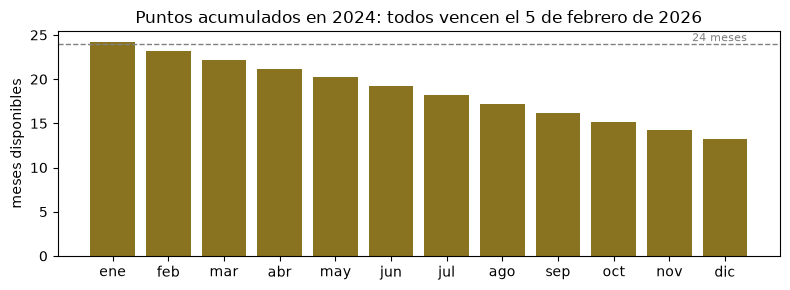

In [20]:
vida = lotes[lotes["periodo"].dt.year == 2024].drop_duplicates("periodo").sort_values("periodo")
vida = vida.assign(meses_de_vida=((vida["vence_el"] - vida["disponible_desde"]).dt.days / 30.44).round(1))
MESES_ES = ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"]

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(MESES_ES, vida["meses_de_vida"], color="#8a7320")
ax.axhline(24, color="grey", linestyle="--", linewidth=1)
ax.text(11.4, 24.3, "24 meses", ha="right", fontsize=8, color="grey")
ax.set_ylabel("meses disponibles")
ax.set_title("Puntos acumulados en 2024: todos vencen el 5 de febrero de 2026")
plt.tight_layout()
plt.show()

Un lote de enero queda disponible unos 24 meses y uno de diciembre, 13. Contado desde el día de la compra, el rango va de 13 a 25 meses. El programa les comunica «dos años» a todos.

### H-6 · La tasa reducida cae sobre el gasto recurrente

In [21]:
reparto = tx.groupby("categoria").agg(consumo_gtq=("monto_gtq", "sum"), puntos=("acreditados", "sum"))
(reparto / reparto.sum() * 100).round(1).rename(columns=lambda c: f"% {c}")

,% consumo_gtq,% puntos
categoria,,
general,52.60,91.90
reducida,47.40,8.10


En la réplica, supermercados, gasolineras y las otras tres categorías reducidas concentran cerca de la mitad del consumo y apenas una fracción de los puntos. El reporte propone medir esa proporción sobre la cartera real.

### H-1 · El mismo saldo no compra lo mismo

La conversión a millas varía según el producto que originó cada punto. Dos grupos con casi el mismo saldo pueden recibir cantidades de millas muy distintas, y ninguno de los dos lo ve en su estado de cuenta.

In [22]:
vigente = lotes[lotes["restante"] > 0].assign(millas=lambda d: d["restante"] * d["origen"].map(MILLAS))
por_grupo = vigente.groupby("grupo_id").agg(saldo=("restante", "sum"), millas=("millas", "sum"))
por_grupo = por_grupo[por_grupo["saldo"] > 1000].sort_values("saldo")
pares = pd.DataFrame({
    "a": por_grupo.index[:-1], "b": por_grupo.index[1:],
    "dif_saldo": por_grupo["saldo"].diff().iloc[1:].to_numpy() / por_grupo["saldo"].iloc[1:].to_numpy(),
    "dif_millas": por_grupo["millas"].diff().abs().iloc[1:].to_numpy(),
})
par = pares[pares["dif_saldo"] < 0.02].nlargest(1, "dif_millas").iloc[0]
composicion = vigente[vigente["grupo_id"].isin([par["a"], par["b"]])].pivot_table(
    index="grupo_id", columns="origen", values="restante", aggfunc="sum", fill_value=0
)
por_grupo.loc[[par["a"], par["b"]]].join(composicion)

,saldo,millas,campana,credito_mastercard,credito_visa,debito_visa,dividelo_todo,saldo_promedio
grupo_id,,,,,,,,
G235,12020,"7,388.40",458,0,0,11528,0,34
G060,12029,"11,981.00",157,2641,6151,0,3000,80


Las tasas de millas son supuestas (P-5), así que la diferencia no tiene magnitud real. El mecanismo sí lo es, y obliga a guardar el origen en cada lote.

### P-1 · El grano del tope cambia el saldo

In [23]:
comparacion = []
for grano in ("tarjeta", "cliente", "grupo_familiar"):
    acreditado = aplicar_tope(tx, grano)
    comparacion.append({
        "grano del tope": grano,
        "puntos acreditados": acreditado.sum(),
        "puntos recortados": (tx["puntos"] - acreditado).sum(),
        "grupos afectados": tx.loc[acreditado < tx["puntos"], "grupo_id"].nunique(),
    })
pd.DataFrame(comparacion)

,grano del tope,puntos acreditados,puntos recortados,grupos afectados
0,tarjeta,8881518,0,0
1,cliente,8881518,0,0
2,grupo_familiar,7889943,991575,7


El mismo consumo da tres saldos distintos según dónde se aplique el tope. Desde fuera no se puede saber cuál usa el banco, y es la primera pregunta del cuestionario al cliente.

### H-4 · El tipo de cambio mueve todos los saldos

In [24]:
sensibilidad = pd.DataFrame(
    [(t, puntos_por_consumo(tx, t).sum()) for t in (7.60, 7.65, 7.70, 7.75, 7.80)],
    columns=["tipo de cambio", "puntos"],
)
sensibilidad["vs 7.70 (%)"] = (sensibilidad["puntos"] / sensibilidad.loc[2, "puntos"] - 1) * 100

usd = np.where(tx["moneda"] == "USD", tx["monto"], tx["monto"] / TC)
exacto = pd.Series(usd, index=tx.index) * np.where(tx["categoria"] == "reducida", TASA_REDUCIDA, TASA_BASE)
por_ciclo = np.floor(exacto.groupby([tx["tarjeta_id"], tx["fecha_hora"].dt.to_period("M")]).sum()).sum()
print(f"Truncar por transacción en lugar de por ciclo: {por_ciclo - tx['puntos'].sum():,.0f} puntos menos para los clientes.")
sensibilidad

Truncar por transacción en lugar de por ciclo: 47,727 puntos menos para los clientes.


,tipo de cambio,puntos,vs 7.70 (%)
0,7.60,8989662,1.22
1,7.65,8935267,0.61
2,7.70,8881518,0.00
3,7.75,8828496,-0.60
4,7.80,8776010,-1.19


Un cambio de cinco centavos en el tipo de cambio mueve el saldo de todos los clientes en todas sus transacciones. El redondeo agrega una pérdida pequeña por compra que, sumada sobre la cartera, deja de ser un decimal.

### H-7 · Los puntos de sorteo no se pueden reconstruir

Los puntos de consumo se recalculan desde el autorizador y los de saldo desde el core de depósitos. Los de sorteo solo existen en el registro del sorteo.

In [25]:
fuente = {
    "credito_visa": "transacciones", "debito_visa": "transacciones", "debito_mastercard": "transacciones",
    "credito_mastercard": "transacciones", "dividelo_todo": "transacciones", "campana": "transacciones + padrón",
    "saldo_promedio": "saldos_promedio", "sorteo": "premios_sorteo",
}
reconstruccion = lotes.groupby("origen").agg(puntos=("puntos", "sum"), grupos=("grupo_id", "nunique"))
reconstruccion["se recalcula desde"] = reconstruccion.index.map(fuente)
reconstruccion["se puede rederivar"] = reconstruccion.index != "sorteo"
reconstruccion

,puntos,grupos,se recalcula desde,se puede rederivar
origen,,,,
campana,51782,145,transacciones + padrón,True
credito_mastercard,385893,63,transacciones,True
credito_visa,5761276,201,transacciones,True
debito_mastercard,474171,73,transacciones,True
debito_visa,900194,116,transacciones,True
dividelo_todo,328401,56,transacciones,True
saldo_promedio,55520,216,saldos_promedio,True
sorteo,120000,116,premios_sorteo,False


Si se pierde premios_sorteo.csv, los puntos de la última fila quedan en el saldo de sus grupos sin ninguna causa que los explique.

### Saldo retenido y pasivo

In [26]:
retenido = saldo[~saldo["puede_canjear"] & (saldo["saldo"] > 0)]
pd.Series({
    "Saldo vigente total (puntos)": saldo["saldo"].sum(),
    "Pasivo ilustrativo en quetzales": saldo["saldo"].sum() * GTQ_POR_PUNTO_CANJE,
    "Puntos que vencen el próximo 5 de febrero": saldo["vence_proximo_corte"].sum(),
    "Grupos con saldo visible que no pueden canjear": len(retenido),
    "Puntos en esos grupos": retenido["saldo"].sum(),
    "Puntos expirados en la réplica": -movimientos.loc[movimientos["tipo"] == "expiracion", "puntos"].sum(),
}).map("{:,.0f}".format).to_frame("valor")

,valor
Saldo vigente total (puntos),"4,570,300"
Pasivo ilustrativo en quetzales,"282,902"
Puntos que vencen el próximo 5 de febrero,"2,781,538"
Grupos con saldo visible que no pueden canjear,47
Puntos en esos grupos,"880,045"
Puntos expirados en la réplica,"1,885,477"


Los grupos con unificación menor a doce meses ven su saldo en los seis canales de consulta y no pueden usarlo. Ningún canal distingue ese estado, y el cliente se entera en el mostrador.

## 8. Dónde entra el modelo

La propuesta de ML pone en primer lugar la resolución del rubro con un LLM de salida cerrada (M1), porque es el único injerto que corrige un cálculo. Su métrica primaria son los puntos acreditados con el factor equivocado, y su referencia a batir es la regla de texto que ya corre en Silver.

La réplica conoce el rubro real de cada consumo porque lo generó, así que puede medir esa métrica para la regla actual.

In [27]:
evaluacion = tx.assign(mcc_real=tx["auth_code"].map(MCC_REAL))
evaluacion["reducida_real"] = evaluacion["mcc_real"].isin(MCC_REDUCIDO)
evaluacion["puntos_correctos"] = np.floor(evaluacion["monto_usd"] * np.where(evaluacion["reducida_real"], TASA_REDUCIDA, TASA_BASE))
mal = evaluacion["puntos"] != evaluacion["puntos_correctos"]

de_mas = (evaluacion["puntos"] - evaluacion["puntos_correctos"])[mal].sum()
pd.Series({
    "Consumos sin código de rubro": f"{(evaluacion['mcc'] == '').sum():,}",
    "Resueltos por descripción": f"{(evaluacion['categoria_origen'] == 'descripcion').sum():,}",
    "Sin resolver, van al motor con tasa base": f"{(evaluacion['categoria_origen'] == 'sin_resolver').sum():,}",
    "Consumos con el factor equivocado": f"{mal.sum():,}",
    "Puntos acreditados de más": f"{de_mas:,.0f}",
    "Porcentaje del total acreditado": f"{de_mas / evaluacion['puntos'].sum():.2%}",
}).to_frame("regla de texto actual")

,regla de texto actual
Consumos sin código de rubro,"14,350"
Resueltos por descripción,"10,179"
"Sin resolver, van al motor con tasa base","4,171"
Consumos con el factor equivocado,"3,012"
Puntos acreditados de más,"259,906"
Porcentaje del total acreditado,2.93%


Todos los errores vienen de descripciones abreviadas que el catálogo no reconoce: supermercados, gasolineras y tiendas de conveniencia que el motor paga a tasa base. Ese número es el que M1 tiene que reducir para entrar al pipeline. El modelo se llamaría una vez por descripción distinta sin resolver y no una vez por transacción, y su respuesta se guardaría en el catálogo para la siguiente corrida.

## 9. Conclusiones

- La arquitectura que las reglas públicas obligan a tener se puede construir en pequeño con cuatro orígenes, tres capas y un ledger de lotes, y cuadra: el saldo de los lotes coincide con la suma de los movimientos.
- Los cuatro supuestos de poc-parameters.yaml (tipo de cambio, tasa de saldo promedio, orden de consumo y tasas de millas) cambian los resultados. Sustituirlos por los valores reales es la forma de convertir esta réplica en una medición.
- La vigencia efectiva, la penalización de la tasa reducida y el grano del tope quedan demostrados como mecanismos con los datos sintéticos. Su magnitud en la cartera real depende de las respuestas a P-1 a P-5.
- La vía de sorteo es la única que no se puede reconstruir desde otra fuente. Su registro tiene que tratarse como parte del ledger.
- El error de rubro cuesta un factor de diez. Por eso la clasificación del comercio es el primer lugar donde tiene sentido un modelo, y la réplica ya calcula la métrica contra la que se evaluaría.

El diagnóstico completo está en el reporte escrito: situación, reglas del programa, hallazgos, conclusiones y referencias.

## Referencias

- Reporte: [docs/report](https://github.com/JosueSay/ml-engineering-portfolio/tree/main/case-studies/reward-system/docs/report)
- Catálogo de reglas con su fuente: [config/assumptions.yaml](https://github.com/JosueSay/ml-engineering-portfolio/blob/main/case-studies/reward-system/config/assumptions.yaml)
- Parámetros supuestos del POC: [config/poc-parameters.yaml](https://github.com/JosueSay/ml-engineering-portfolio/blob/main/case-studies/reward-system/config/poc-parameters.yaml)
- Arquitectura de datos y diagramas: [docs/architecture](https://github.com/JosueSay/ml-engineering-portfolio/tree/main/case-studies/reward-system/docs/architecture)
- Propuesta de ML, AI y LLM: [docs/proposal/ml-ai-llm.md](https://github.com/JosueSay/ml-engineering-portfolio/blob/main/case-studies/reward-system/docs/proposal/ml-ai-llm.md)
- Portal Bi Puntos: https://bipuntos.bi.com.gt/
- Puntos Bi, Tarjetas Bi: https://www.corporacionbi.com/gt/tarjetasbi/puntos-bi/
- Preguntas frecuentes de Club Bi: https://www.corporacionbi.com/gt/bancoindustrial/preguntas-frecuentes-club-bi/

Repositorio: https://github.com/JosueSay/ml-engineering-portfolio, en case-studies/reward-system.